In [1]:
import os
import pandas as pd
import numpy as np
import glob

import matplotlib.pyplot as plt
from datetime import datetime, timedelta
from astropy.time import Time
import glob as glob

from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import connected_components
import gc

In [169]:
window_T, window_F = 0.1, 20                       # clustering windows
min_triggers, clust, run = 20, 'gdchar', 'O3a'

filterr = False
deltat = 2.0

sufixo = '_filtered_' if filterr else '_'
cut = 'cut' + str(min_triggers)

In [170]:
base = os.getcwd()
repository = '/home/esanches/Projetos/tSNE/Virgo/zrepository'
daily_clustering = repository + '/' + clust + '/' + run + '/daily_clustering' + cut

## Functions

In [84]:
def glitch_to_glitchgram(unclustered, clustered, deltat, 
                         fmin=3, fmax=8192, tbins=41, fbins=30):
    
    all_glitchgrams = []
    
    """
    This function create one glitchgram from unclustered Omicron data, for each glitch.

    Parameters:
        df_triggers (dataFrame): A dataFrame of GPStimes of all triggers inside of some window.
        tmin, tmax (numbers): limits of GPStimes that contain all triggers of some glitch.
        fmin, fmax (numbers): frequency range for the glitchgram.
        n_time_bins (int): number of time bins.
        n_freq_bins (int): number of frequency bins.
        norm (boolean): True if you need normalize SNR values.

    Returns:
        array for some glitch: each entry is a SNR value from flattened (binsf × binst) matrix.
    """

    times_all = unclustered['time'].values
    freqs_all = unclustered['frequency'].values
    snrs_all  = unclustered['snr'].values

    time_edges = np.linspace(-deltat/2, deltat/2, tbins+1)
    freq_edges = np.logspace(np.log10(fmin), np.log10(fmax), fbins+1)
    
    for i, row in enumerate(clustered.itertuples(index=False)):

        #t_center = getattr(row, 'GPStime')
        t_center = row.time
    
        tmin = t_center - deltat/2
        tmax = t_center + deltat/2
    
        i0 = np.searchsorted(times_all, tmin, side="left")
        i1 = np.searchsorted(times_all, tmax, side="right")
    
        times = times_all[i0:i1] - t_center
        freqs = freqs_all[i0:i1]
        snrs  = snrs_all[i0:i1]

        '''if len(times) < 10: # Equivalente ao tcut
            continue'''
    
        df_triggers = pd.DataFrame({'time': times,'frequency': freqs,'snr': snrs})
        
        t_idx = np.digitize(df_triggers['time'].values, time_edges) - 1
        f_idx = np.digitize(df_triggers['frequency'].values, freq_edges) - 1
            
        # initial empty matrix
        A = np.zeros((fbins, tbins), dtype=float)
    
        for ti, fi, si in zip(t_idx, f_idx, snrs):
            if 0 <= ti < tbins and 0 <= fi < fbins:
                if si > A[fi, ti]:
                    A[fi, ti] = si
                    
        '''# normalização do SNR 
        if len(snrs) > 0:
            snr_min = snrs.min()
            snr_max = snrs.max()
            if snr_max > snr_min:
                norm_snrs = (snrs - snr_min) / (snr_max - snr_min)
            else:
                norm_snrs = np.zeros_like(snrs)
        else:
            norm_snrs = snrs'''

        all_glitchgrams.append(A)
    
    return all_glitchgrams

In [28]:
def filter_intervals(gps_start, gps_end, intervals):
    intervals_crop = intervals[(intervals['int2'] >= gps_start) & (intervals['int1'] <= gps_end)].sort_values('int1')
    intervals_crop['int1'] = intervals_crop['int1'].astype('float64')
    
    total_triggers_winddow = 0
    filtered_chunks = []
    
    for chunk in pd.read_csv(basedata + '/triggers_total.csv', chunksize=10000000):
    
        chunk['time'] = chunk['time'].astype('float64')
        
        chunk = chunk[(chunk['time'] >= gps_start) & (chunk['time'] <= gps_end)].sort_values('time')
        if chunk.empty:
            continue
    
        total_triggers_winddow += len(chunk)
        
        merged = pd.merge_asof(chunk, intervals_crop, left_on='time', right_on='int1', direction='backward')
        valid = merged[(merged['time'] >= merged['int1']) & (merged['time'] <= merged['int2'])]

        if not valid.empty:
            filtered_chunks.append(valid[['time', 'frequency', 'snr']])
    if not filtered_chunks:
        return pd.DataFrame(columns=['time', 'frequency', 'snr'])
    
    triggers_crop = pd.concat(filtered_chunks, ignore_index=True)

    return triggers_crop

In [29]:
def clusterize_triggers1D(gltab, window, min_triggers):
    
    if len(gltab) == 0:
        return pd.DataFrame()

    table = gltab.copy()
    table = table.sort_values(by='time').reset_index(drop=True)

    times = table['time'].values
    deltas = times[1:] - times[:-1]

    new_cluster_mask = np.concatenate([[False], deltas > window])
    cluster_ids = np.cumsum(new_cluster_mask)

    table['cluster'] = cluster_ids

    # filter: Retains only clusters with "min_triggers" or more triggers
    counts = table['cluster'].value_counts()
    valid_clusters = counts[counts >= min_triggers].index
    
    table_filtered = table[table['cluster'].isin(valid_clusters)]

    if table_filtered.empty:
        return pd.DataFrame()
    
    # groups by cluster and extracts the representative (row with the highest SNR) + extremes
    summary_rows = []

    print(table_filtered)
    
    for cl, group in table_filtered.groupby('cluster'):
        # Encontra o trigger com maior SNR dentro deste grupo
        max_row = group.loc[group['snr'].idxmax()]

        summary_rows.append({
            'cluster': cl,
            'num_triggers': len(group), # quantidade de triggers no cluster
            'tstart': group['time'].min(),
            'tend': group['time'].max(),
            'time': max_row['time'],
            'frequency': max_row['frequency'],
            'min_freq': group['frequency'].min(),
            'max_freq': group['frequency'].max(),
            'snr': max_row['snr']
        })

    return pd.DataFrame(summary_rows)

In [30]:
def clusterize_triggers2D(gltab, window_T, window_F, min_triggers):

    if len(gltab) == 0:
        return pd.DataFrame()

    table = gltab.copy()

    times = table['time'].values
    freqs = table['frequency'].values
    n = len(times)

    # sort by time
    sort_idx = np.argsort(times)
    times_sorted = times[sort_idx]
    freqs_sorted = freqs[sort_idx]
    
    connections = []

    # for each trigger, look ONLY at the subsequent ones that fall within the time window
    for i in range(n):
        t_curr = times_sorted[i]
        f_curr = freqs_sorted[i]

        # searches only for candidates within the time window t_curr + window_T
        for j in range(i + 1, n):
            if times_sorted[j] - t_curr > window_T:
                break

            # tests the frequency condition
            if abs(freqs_sorted[j] - f_curr) /f_curr <= window_F:
                
                # connects trigger i to trigger j
                connections.append((sort_idx[i], sort_idx[j]))
    
    # form groupss based on the connections found
    if connections:
        pairs = np.array(connections)
        data = np.ones(len(pairs), dtype=bool)
        adj = csr_matrix((data, (pairs[:, 0], pairs[:, 1])), shape=(n, n))
        _, cluster_ids = connected_components(csgraph=adj, directed=False)
    else:
        cluster_ids = np.arange(n)

    table['cluster'] = cluster_ids

    # filter: Retains only clusters with "min_triggers" or more triggers
    counts = table['cluster'].value_counts()
    valid_clusters = counts[counts >= min_triggers].index
    
    table_filtered = table[table['cluster'].isin(valid_clusters)]

    if table_filtered.empty:
        return pd.DataFrame()
    
    # groups by cluster and extracts the representative (row with the highest SNR) + extremes
    summary_rows = []
    
    for cl, group in table_filtered.groupby('cluster'):
        # Encontra o trigger com maior SNR dentro deste grupo
        max_row = group.loc[group['snr'].idxmax()]

        summary_rows.append({
            'cluster': cl,
            'num_triggers': len(group), # quantidade de triggers no cluster
            'tstart': group['time'].min(),
            'tend': group['time'].max(),
            'time': max_row['time'],
            'frequency': max_row['frequency'],
            'min_freq': group['frequency'].min(),
            'max_freq': group['frequency'].max(),
            'snr': max_row['snr']
        })

    return pd.DataFrame(summary_rows)

In [31]:
def run_routine(current_day, end_day, intervals, min_triggers, output_dir, global_cluster_ID=0):

    # creates the folder to save the daily records, if it doesn't existt
    os.makedirs(output_dir, exist_ok=True)
    
    # clustered_list = []
    trigger_count = []
    glitch_count = []

    '''gps_start_filt = Time(current_day, scale="utc").gps
    gps_end_filt = Time(end_day, scale="utc").gps

    triggers_crop = filter_intervals(gps_start_filt, gps_end_filt, intervals)'''
    
    while current_day <= end_day:

        date_str = current_day.strftime('%Y-%m-%d')
        out_file = os.path.join(output_dir, f"glitches_{date_str}.parquet")

        # skip if the day has already been processed and saved
        if os.path.exists(out_file):
            print(f"Day {date_str} already processed. Skipping...")
            current_day += timedelta(days=1)
            continue
        
        # declare the start and end of the current day
        day_start = datetime(current_day.year, current_day.month, current_day.day, 0, 0, 0)
        day_end   = datetime(current_day.year, current_day.month, current_day.day, 23, 59, 59)
    
        print(f"Processing day: {current_day.date()}")
    
        # convert the time to gpsTIME
        gps_start = Time(day_start, scale="utc").gps
        gps_end   = Time(day_end, scale="utc").gps

        # loads and filters only the triggers for the current day
        gltab = filter_intervals(gps_start, gps_end, intervals)
        
        '''
        # limit the intervals to the current day only
        day_interval = intervals[(intervals['int2'] >= gps_start) & (intervals['int1'] <= gps_end)].copy()
        
        # cut intervals before gps_start and after gps_end
        day_interval['start_recortado'] = day_interval['int1'].clip(lower=gps_start)
        day_interval['end_recortado']   = day_interval['int2'].clip(upper=gps_end)
    
        # duration of the intervals of the current day
        day_duration_sec = (day_interval['end_recortado'] - day_interval['start_recortado']).sum()
        day_duration_hrs = day_duration_sec / 3600
    
        print(f'Opening hours for this day: {day_duration_hrs:.2f}')
    
        # triggers of the current day
        trigfiles = triggers_crop[(triggers_crop['time'] >= gps_start) & (triggers_crop['time'] <= gps_end)]
        gltab = trigfiles.copy()

        del trigfiles, day_interval
        '''
        
        num_trigggers = len(gltab)
        trigger_count.append(num_trigggers)
        print(f'Triggers count for this day: {num_trigggers}\n')
    
        # CLUSTERING OF THE CURRENT DAY
        if not gltab.empty:
            gltab = gltab.sort_values(by="time").drop_duplicates(subset=["time"]).reset_index(drop=True)
    
            # the MAIN FUNCTION of this clustering process
            # clustered = clusterize_triggers1D(gltab, window_T, min_triggers)
            clustered = clusterize_triggers2D(gltab, window_T, window_F, min_triggers)

            num_glitches = len(clustered)
            glitch_count.append(num_glitches)
            print(f'\nGlitches count for this day: {num_glitches}\n')
            
            # adds the day's result to the list if there are glitches
            if not clustered.empty:
                
                # adjusts the day's IDs by adding the accumulated ID
                clustered['cluster'] += global_cluster_ID
    
                # update the ID for the next day to avoid repeating numbers
                global_cluster_ID = clustered['cluster'].max() + 1

                abs_out_file = os.path.abspath(out_file)

                try:
                    # salva o dia no disco
                    clustered.to_parquet(abs_out_file, index=False)
                    print(f"Successfully saved: {out_file}")
                except Exception as e:
                    csv_file = abs_out_file.replace('.parquet', '.csv')
                    clustered.to_csv(csv_file, index=False)
                    print(f"parquet failed ({e}). SAVED IN CSV in: {csv_file}")
                # clustered_list.append(clustered)

                del clustered
        else:
            glitch_count.append(0)
            print("Glitches count for this day: 0")

        del gltab
        
        # forces the release of unused RAM
        gc.collect()
        
        current_day += timedelta(days=1)

    """
    del triggers_crop
    gc.collect()
    """

    # final concatenation reading files from the disk
    print("Concatenating results saved to disk...")
    saved_files = sorted(glob.glob(os.path.join(output_dir, "glitches_*.parquet")))

    if saved_files:
        df_list = [pd.read_parquet(f) for f in saved_files]
        df_glitches_final = pd.concat(df_list, ignore_index=True)
        del df_list
        gc.collect()
    else:
        df_glitches_final = pd.DataFrame()

    return df_glitches_final, trigger_count, glitch_count

    # appends to the FINAL DataFrame every day
    """
    if clustered_list:
        df_glitches_final = pd.concat(clustered_list, ignore_index=True)
    else:
        df_glitches_final = pd.DataFrame()

    return df_glitches_final
    """

## Run the routine

In [92]:
start_day_O3a = datetime(2019, 4, 1, 0, 0, 0)
end_day_O3a   = datetime(2019, 10, 1, 15, 0, 0)

start_day_O3b = datetime(2019, 11, 1, 15, 0, 0)
end_day_O3b   = datetime(2020, 3, 27, 17, 0, 0)

# gps_start = Time(start_day_O3b, scale="utc").gps
# gps_end = Time(end_day_O3b, scale="utc").gps

In [93]:
start_days = {
    'O3a': start_day_O3a, 'O3b': start_day_O3b
}
end_days = {
    'O3a': end_day_O3a, 'O3b': end_day_O3b
}
start = start_days[run]
end = end_days[run]

In [100]:
intervals = pd.read_csv(base + '/zrepository/gwosc' + run + '.txt', sep=' ', header=None, names=['int1', 'int2', 'duration'])

intervals_hour = intervals['duration'].values.sum() / 3600
intervals_hour

np.float64(3344.1469444444447)

run routine:

In [ ]:
df_glitches_final = run_routine(start, end, intervals, min_triggers, output_dir=daily_clustering)

## Combine and save the .parquet files

In [95]:
base

'/home/esanches/Projetos/tSNE/Virgo'

In [96]:
daily_clustering

'/home/esanches/Projetos/tSNE/Virgo/zrepository/gdchar/O3a/daily_clustering_cut20'

In [97]:
arquivos_parquet = sorted(glob.glob(os.path.join(daily_clustering, "glitches_*.parquet")))

print(f"reading {len(arquivos_parquet)} daily files...")

df_list = [pd.read_parquet(f) for f in arquivos_parquet]
df_glitches_final = pd.concat(df_list, ignore_index=True)

arquivo_csv_saida = base + '/' + clust + run + cut + '.csv'
df_glitches_final.to_csv(arquivo_csv_saida, index=False)

print(f"completed! Total of {len(df_glitches_final):,} glitches saved in:")
print(os.path.abspath(arquivo_csv_saida))

reading 184 daily files...
completed! Total of 131,204 glitches saved in:
/home/esanches/Projetos/tSNE/Virgo/gdcharO3a_cut20.csv


## Glitches per hour

calcular os intervals da O3a para ver o glitch per hour V

In [112]:
base

'/home/esanches/Projetos/tSNE/Virgo'

In [113]:
intervals = pd.read_csv(base + '/zrepository/gwosc' + run + '.txt', sep=' ', header=None, names=['int1', 'int2', 'duration'])
intervals_hour = intervals['duration'].values.sum() / 3600
intervals_hour

np.float64(3344.1469444444447)

In [129]:
repository

'/home/esanches/Projetos/tSNE/Virgo/zrepository'

In [138]:
glitches = pd.read_csv(repository + '/' + clust + '/' + run + '/' + 'clustered' + sufixo + cut + '.csv')
len(glitches)

80769

In [137]:
glitch_per_hour = len(glitches) / intervals_hour
glitch_per_hour

np.float64(24.15234777113479)

calcular os intervals da O3b

In [4]:
base

'/home/esanches/Projetos/tSNE/Virgo'

In [5]:
intervals = pd.read_csv(base + '/zrepository/gwosc' + run + '.txt', sep=' ', header=None, names=['int1', 'int2', 'duration'])
intervals_hour = intervals['duration'].values.sum() / 3600
intervals_hour

np.float64(2664.224166666667)

In [6]:
repository

'/home/esanches/Projetos/tSNE/Virgo/zrepository'

In [9]:
repository + '/' + clust + '/' + run + '/' + 'clustered' + sufixo + cut + '.csv'

'/home/esanches/Projetos/tSNE/Virgo/zrepository/gdchar/O3b/clustered_cut20.csv'

In [7]:
glitches = pd.read_csv(repository + '/' + clust + '/' + run + '/' + 'clustered' + sufixo + cut + '.csv')
len(glitches)

351929

In [8]:
glitch_per_hour = len(glitches) / intervals_hour
glitch_per_hour

np.float64(132.09436518260944)

## Comparison of gdchar and gspy timings O3a

our clustering glitches are

In [187]:
repository

'/home/esanches/Projetos/tSNE/Virgo/zrepository'

In [188]:
gdchar_data = pd.read_csv(repository + '/' + clust + '/' + run + '/' + 'clustered' + sufixo + cut + '.csv')
gdchar_data

,time,frequency,snr
0,1.238166e+09,138.375243,11.157326
1,1.238167e+09,19.453599,8.515493
2,1.238167e+09,21.824261,8.541214
3,1.238168e+09,19.494597,7.698744
4,1.238168e+09,336.991363,10.627294
...,...,...,...
80764,1.253975e+09,32.842241,12.071470
80765,1.253977e+09,1079.892919,89.686901
80766,1.253977e+09,20.025103,8.843882
80767,1.253977e+09,20.317121,8.158477


gravity spy O3a glitches are

In [189]:
gspy_data = pd.read_csv(base + '/gspy' + run + '.csv')
gspy_data = gspy_data[gspy_data['confidence'] >= 0.9]

gspy_data.tail()

,GPStime,peakFreq,snr,amplitude,centralFreq,duration,bandwidth,chisq,chisqDof,confidence,id,ifo,label,imgUrl,Q-value
46190,1.238478e+09,24.329,9.116,1.540000e-21,1267.535,2.000,2503.070313,0.0,0.0,0.9,BWL5uUnNyu,V1,Scattered_Light,https://ldas-jobs.ligo.caltech.edu/~gravityspy...,22.627
46191,1.253434e+09,19.292,8.315,1.750000e-21,1161.367,1.500,2290.733643,0.0,0.0,0.9,Djty5Vsg79,V1,Low_Frequency_Lines,https://ldas-jobs.ligo.caltech.edu/~gravityspy...,45.255
46192,1.244794e+09,422.792,9.344,1.590000e-22,4014.908,0.347,7281.335449,0.0,0.0,0.9,bfA6S3f6iy,V1,Whistle,https://ldas-jobs.ligo.caltech.edu/~gravityspy...,45.255
46193,1.239700e+09,27.033,8.944,5.990000e-22,3985.119,1.292,7930.728027,0.0,0.0,0.9,uoj0FaSv2R,V1,Scattered_Light,https://ldas-jobs.ligo.caltech.edu/~gravityspy...,45.255
46194,1.252496e+09,19.991,8.548,3.010000e-21,18.965,1.750,5.929210,0.0,0.0,0.9,OYupBQDSaw,V1,Low_Frequency_Lines,https://ldas-jobs.ligo.caltech.edu/~gravityspy...,45.255


In [216]:
gdchar_sorted = gdchar_data.sort_values("time")
gspy_sorted = gspy_data.sort_values("GPStime")

matched_df = pd.merge_asof(gspy_sorted, gdchar_sorted, left_on="GPStime", right_on="time", direction="nearest", tolerance=0.1)

matched_raw = matched_df.dropna(subset=["time"]).copy()
matched_raw["dt"] = (matched_raw["GPStime"] - matched_raw["time"]).abs()

matched = matched_raw.sort_values("dt").drop_duplicates(subset=["time"]).drop(columns=["dt"]).sort_index().reset_index(drop=True)

non_matched_gspy = gspy_sorted[~gspy_sorted["GPStime"].isin(matched["GPStime"])].reset_index(drop=True)
non_matched_gdchar = gdchar_sorted[~gdchar_sorted["time"].isin(matched["time"])].reset_index(drop=True)

In [217]:
x = len(gdchar_sorted) - len(matched)  # red arrows
x

58252

In [218]:
y = len(gspy_sorted) - len(matched)   # blue arrows
y

23678

In [219]:
print(f'non_matched_gspy: {len(non_matched_gspy)}\n\nnon_matched_gdchar: {len(non_matched_gdchar)}')

non_matched_gspy: 23144

non_matched_gdchar: 58252


In [222]:
diff = len(matched) / len(gspy_sorted)
diff

0.4874337049464228

In [223]:
matched.tail()

,GPStime,peakFreq,snr_x,amplitude,centralFreq,duration,bandwidth,chisq,chisqDof,confidence,id,ifo,label,imgUrl,Q-value,time,frequency,snr_y
22512,1.253971e+09,24.364,7.950,7.230000e-22,24.212,1.250,4.56584,0.0,0.0,0.960,BmuuLBFhBz,V1,Scattered_Light,https://ldas-jobs.ligo.caltech.edu/~gravityspy...,45.255,1.253971e+09,24.524402,7.754828
22513,1.253973e+09,26.116,11.241,8.380000e-22,26.590,4.000,21.17977,0.0,0.0,0.973,DWIpgR4YTP,V1,Scattered_Light,https://ldas-jobs.ligo.caltech.edu/~gravityspy...,45.255,1.253973e+09,26.358692,12.839114
22514,1.253973e+09,25.673,7.946,6.170000e-22,26.140,1.375,12.77182,0.0,0.0,0.960,9zQkzhergo,V1,Low_Frequency_Burst,https://ldas-jobs.ligo.caltech.edu/~gravityspy...,11.314,1.253973e+09,25.851009,8.372283
22515,1.253974e+09,24.104,9.501,9.300000e-22,26.590,1.000,21.17977,0.0,0.0,0.996,B9sr97s6ss,V1,Low_Frequency_Burst,https://ldas-jobs.ligo.caltech.edu/~gravityspy...,22.627,1.253974e+09,24.896957,8.630393
22516,1.253977e+09,20.168,9.750,1.910000e-21,3983.241,4.748,7934.48291,0.0,0.0,0.951,elTP3iCl5U,V1,Scattered_Light,https://ldas-jobs.ligo.caltech.edu/~gravityspy...,22.627,1.253977e+09,20.025103,8.843882


In [224]:
non_matched_gspy.tail()

,GPStime,peakFreq,snr,amplitude,centralFreq,duration,bandwidth,chisq,chisqDof,confidence,id,ifo,label,imgUrl,Q-value
23139,1.253972e+09,31.018,7.961,3.720000e-22,30.500,1.156,12.218920,0.0,0.0,0.959,56KvhkOCa5,V1,None_of_the_Above,https://ldas-jobs.ligo.caltech.edu/~gravityspy...,11.314
23140,1.253972e+09,26.904,8.155,4.320000e-22,2169.502,1.500,4307.003418,0.0,0.0,0.998,L4j9cv8xTN,V1,Scattered_Light,https://ldas-jobs.ligo.caltech.edu/~gravityspy...,45.255
23141,1.253974e+09,28.770,10.982,4.620000e-22,36.338,2.250,40.676109,0.0,0.0,1.000,bZxeYIHNwV,V1,Scattered_Light,https://ldas-jobs.ligo.caltech.edu/~gravityspy...,45.255
23142,1.253974e+09,30.278,12.798,4.350000e-22,592.631,1.750,1153.261353,0.0,0.0,1.000,khoKF0Cjhf,V1,Scattered_Light,https://ldas-jobs.ligo.caltech.edu/~gravityspy...,45.255
23143,1.253975e+09,19.896,7.619,1.410000e-21,3909.822,1.500,7783.627441,0.0,0.0,0.991,8WQeFNzWf4,V1,Low_Frequency_Lines,https://ldas-jobs.ligo.caltech.edu/~gravityspy...,45.255


In [225]:
non_matched_gdchar.tail()

,time,frequency,snr
58247,1.253974e+09,27.906247,7.632426
58248,1.253975e+09,32.842241,12.071470
58249,1.253977e+09,1079.892919,89.686901
58250,1.253977e+09,20.317121,8.158477
58251,1.253977e+09,22.811897,7.658416


### Calculate matched by tolerance values

In [191]:
tolerance = [0.1, 0.2, 0.3, 0.4, 0.5, 1.0, 2.0, 5.0]
matched = [38098, 41272, 42632, 43439, 44156, 46045, 48356, 53055]

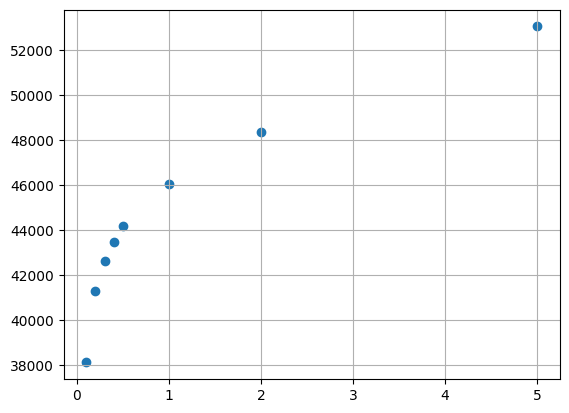

In [192]:
plt.scatter(tolerance, matched)
plt.grid()
plt.show()

In [33]:
'''# Filtra só os novos eventos que entraram com a tolerância de 0.2s
novos_matches = matched_06[~matched_06["id"].isin(matched_05["id"])]

# Veja a diferença média de frequência (deve ser próxima de zero se forem o mesmo glitch)
diff_freq = abs(novos_matches["peakFreq"] - novos_matches["frequency"])
print(
    f"Diferença média de frequência nos novos eventos: {diff_freq.mean():.2f} Hz"
)'''

'# Filtra só os novos eventos que entraram com a tolerância de 0.2s\nnovos_matches = matched_06[~matched_06["id"].isin(matched_05["id"])]\n\n# Veja a diferença média de frequência (deve ser próxima de zero se forem o mesmo glitch)\ndiff_freq = abs(novos_matches["peakFreq"] - novos_matches["frequency"])\nprint(\n    f"Diferença média de frequência nos novos eventos: {diff_freq.mean():.2f} Hz"\n)'

In [32]:
'''import numpy as np

# A mediana é menos sensível a outliers (glitches de frequências muito altas)
print(
    f"Diferença mediana de frequência: {diff_freq.median():.2f} Hz"
)

# Histograma rápido para visualizar o alinhamento
plt.figure(figsize=(8, 4))
plt.hist(diff_freq, bins=50, range=(0, 100), edgecolor="black")
plt.xlabel("|peakFreq - frequency| (Hz)")
plt.ylabel("Contagem")
plt.title("Distribuição do Erro de Frequência (Tolerância 0.2s)")
plt.show()'''

'import numpy as np\n\n# A mediana é menos sensível a outliers (glitches de frequências muito altas)\nprint(\n    f"Diferença mediana de frequência: {diff_freq.median():.2f} Hz"\n)\n\n# Histograma rápido para visualizar o alinhamento\nplt.figure(figsize=(8, 4))\nplt.hist(diff_freq, bins=50, range=(0, 100), edgecolor="black")\nplt.xlabel("|peakFreq - frequency| (Hz)")\nplt.ylabel("Contagem")\nplt.title("Distribuição do Erro de Frequência (Tolerância 0.2s)")\nplt.show()'

## Comparison of gdchar and gspy timings O3b

In [37]:
repository

'/home/esanches/Projetos/tSNE/Virgo/zrepository'

In [38]:
gdchar_data = pd.read_csv(repository + '/' + clust + '/' + run + '/' + 'clustered' + sufixo + cut + '.csv')
gdchar_data.tail()

,time,frequency,snr
351924,1.269363e+09,26.036787,11.241099
351925,1.269363e+09,23.366552,7.607697
351926,1.269363e+09,20.626565,11.607712
351927,1.269363e+09,23.366552,9.897750
351928,1.269364e+09,19.494597,11.711644


In [41]:
gspy_data = pd.read_csv(base + '/gspy' + run + '.csv')
gspy_data.tail()

,GPStime,peakFreq,snr,amplitude,centralFreq,duration,bandwidth,chisq,chisqDof,confidence,id,ifo,label,imgUrl,Q-value
187764,1.258860e+09,149.519,7.755,2.230000e-22,3644.837,0.298,7006.791016,0.0,0.0,0.193,BNSsPWNZxL,V1,None_of_the_Above,https://ldas-jobs.ligo.caltech.edu/~gravityspy...,45.255
187765,1.263986e+09,439.079,10.763,3.140000e-22,4008.574,0.586,7734.266113,0.0,0.0,0.189,mFIpYskZfA,V1,Low_Frequency_Lines,https://ldas-jobs.ligo.caltech.edu/~gravityspy...,45.255
187766,1.258221e+09,149.519,12.079,5.240000e-22,4041.092,1.500,7818.782227,0.0,0.0,0.182,F03pbnKrAv,V1,Light_Modulation,https://ldas-jobs.ligo.caltech.edu/~gravityspy...,45.255
187767,1.258316e+09,1881.682,10.727,6.380000e-22,3881.874,3.568,7731.748047,0.0,0.0,0.182,xYHTG6ENZ0,V1,None_of_the_Above,https://ldas-jobs.ligo.caltech.edu/~gravityspy...,45.255
187768,1.269283e+09,345.868,7.662,1.310000e-22,2341.361,0.172,4067.595459,0.0,0.0,0.175,tSZOu88gaB,V1,Whistle,https://ldas-jobs.ligo.caltech.edu/~gravityspy...,45.255


In [42]:
gdchar_sorted = gdchar_data.sort_values("time")
gspy_sorted = gspy_data.sort_values("GPStime")

matched_df = pd.merge_asof(gspy_sorted, gdchar_sorted, left_on="GPStime", right_on="time", direction="nearest", tolerance=0.1)

matched = matched_df.dropna(subset=["time"]).reset_index(drop=True)
non_matched = matched_df[matched_df["time"].isna()].reset_index(drop=True)

matched

,GPStime,peakFreq,snr_x,amplitude,centralFreq,duration,bandwidth,chisq,chisqDof,confidence,id,ifo,label,imgUrl,Q-value,time,frequency,snr_y
0,1.256656e+09,27.101,9.135,5.410000e-22,3146.814,1.500,6261.627930,0.0,0.0,0.983,VkHVncqAFL,V1,Low_Frequency_Burst,https://ldas-jobs.ligo.caltech.edu/~gravityspy...,5.657,1.256656e+09,26.742411,8.100690
1,1.256656e+09,27.101,10.684,6.330000e-22,30.952,0.750,29.904301,0.0,0.0,0.995,J03w2hULh5,V1,None_of_the_Above,https://ldas-jobs.ligo.caltech.edu/~gravityspy...,5.657,1.256656e+09,26.742411,10.009371
2,1.256656e+09,30.659,12.022,5.210000e-22,36.338,2.250,40.676109,0.0,0.0,0.510,BjuVx1qECE,V1,Extremely_Loud,https://ldas-jobs.ligo.caltech.edu/~gravityspy...,5.657,1.256656e+09,32.842241,11.779653
3,1.256656e+09,27.344,8.552,4.970000e-22,3300.554,1.500,6561.598145,0.0,0.0,0.897,d8cGC7td9D,V1,None_of_the_Above,https://ldas-jobs.ligo.caltech.edu/~gravityspy...,11.314,1.256656e+09,28.940285,8.111036
4,1.256656e+09,27.101,7.810,4.650000e-22,26.590,0.125,21.179770,0.0,0.0,0.983,HgGBG9Ke8X,V1,None_of_the_Above,https://ldas-jobs.ligo.caltech.edu/~gravityspy...,5.657,1.256656e+09,26.742411,8.552043
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
132199,1.269363e+09,19.240,8.443,2.200000e-21,2836.932,2.091,5641.863770,0.0,0.0,0.986,uUf4S0z0OS,V1,Low_Frequency_Lines,https://ldas-jobs.ligo.caltech.edu/~gravityspy...,22.627,1.269363e+09,19.494597,8.171672
132200,1.269363e+09,29.751,15.614,7.470000e-22,36.338,2.500,40.676109,0.0,0.0,1.000,d4M3CTGdKD,V1,Scattered_Light,https://ldas-jobs.ligo.caltech.edu/~gravityspy...,22.627,1.269363e+09,29.544662,14.267237
132201,1.269363e+09,22.632,7.697,9.750000e-22,2379.561,1.125,4723.104980,0.0,0.0,0.545,3CoyNB9Jsm,V1,Scattered_Light,https://ldas-jobs.ligo.caltech.edu/~gravityspy...,22.627,1.269363e+09,23.366552,7.607697
132202,1.269363e+09,21.276,12.997,2.090000e-21,3307.927,3.250,6583.853516,0.0,0.0,0.939,HKw1B9JurK,V1,Low_Frequency_Burst,https://ldas-jobs.ligo.caltech.edu/~gravityspy...,22.627,1.269363e+09,20.626565,11.607712


In [48]:
corr = len(matched) / len(gspy_data)
corr

0.7040778829306222

## Observe the gitchgrams from O3a

### Read the triggers

In [15]:
tperc, trigg_size = 0.7, 359385802
trigcols = ['time', 'frequency', 'snr']
ntrig = int(trigg_size*tperc)

In [17]:
base

'/home/esanches/Projetos/tSNE/Virgo'

In [18]:
""" Performs a random and filtered read of a large CSV file to save memory """

np.random.seed(42)
skip_logic = lambda i: i > 0 and np.random.random() > tperc
trigg = pd.read_csv(base + '/' + 'triggers_total.csv', skiprows=skip_logic, usecols=trigcols)
trigg = trigg.sort_values('time').reset_index(drop=True)
unclustered = trigg.copy()

In [19]:
unclustered.tail()

,time,frequency,snr
251583700,1.269672e+09,1426.656564,6.905275
251583701,1.269672e+09,474.735572,55.750837
251583702,1.269672e+09,1280.344030,8.660046
251583703,1.269672e+09,1079.892919,15.370766
251583704,1.269672e+09,879.323062,19.674751


### Generate MATCHED glitchgrams

In [272]:
cluster = matched.copy()

clustered_gdchar = cluster[['time', 'frequency', 'snr_x']]
clustered_gspy = cluster[['GPStime', 'peakFreq', 'snr_y']].rename(columns={'GPStime': 'time'})

In [273]:
len(clustered_gdchar)

22517

In [274]:
len(clustered_gspy)

22517

In [275]:
matrices_match_gdchar = glitch_to_glitchgram(unclustered, clustered_gdchar, deltat)
matrices_match_gspy = glitch_to_glitchgram(unclustered, clustered_gspy, deltat)

In [276]:
arr_gdchar = np.array(matrices_match_gdchar)
arr_gspy = np.array(matrices_match_gspy)

### Glitchgrams comparison

In [278]:
def plot_comparison(indices_sorteados, array, title, run):
    fig, axes = plt.subplots(2, 5, figsize=(10,4))
    axes = axes.flatten()
    
    fig.suptitle(f"{run} Matrices {title}", fontsize=12, fontweight='bold')
    
    for i, idx in enumerate(indices_sorteados):
        
        matriz = array[idx]
        ax = axes[i]
        
        im = ax.imshow(matriz)
        ax.set_title(f"Glitch #{idx}")
    
    plt.tight_layout()
    plt.show()

In [300]:
seed = 42
np.random.seed(seed)

num_total = len(arr_gdchar)
indices_sorteados = np.random.choice(num_total, size=10, replace=False)

indices_sorteados

array([16494, 15537, 11892,  5496,  4645,  8158, 21370,  9041, 18143,
       14576])

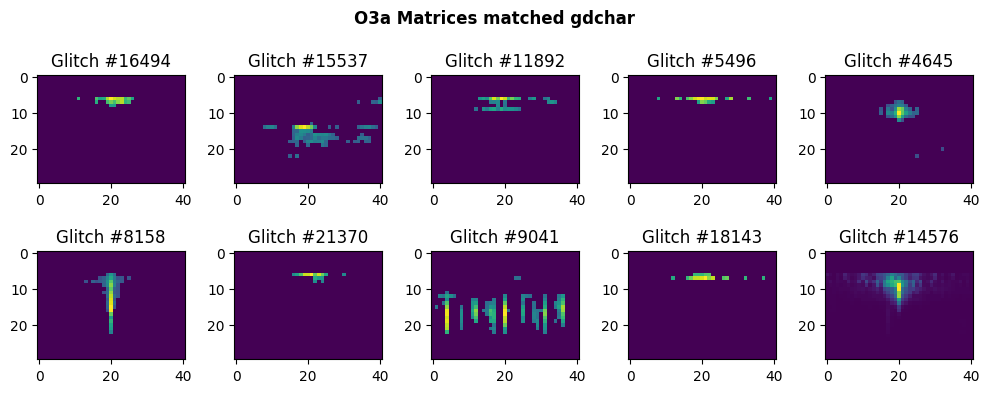

In [280]:
plot_comparison(indices_sorteados, arr_gdchar, 'matched gdchar', run)

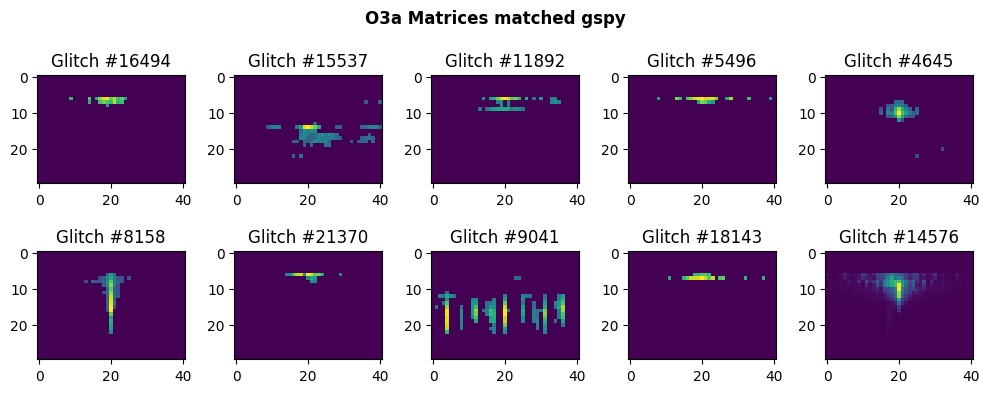

In [281]:
plot_comparison(indices_sorteados, arr_gspy, 'matched gspy', run)

In [284]:
matrice_diff = abs(arr_gdchar - arr_gspy)

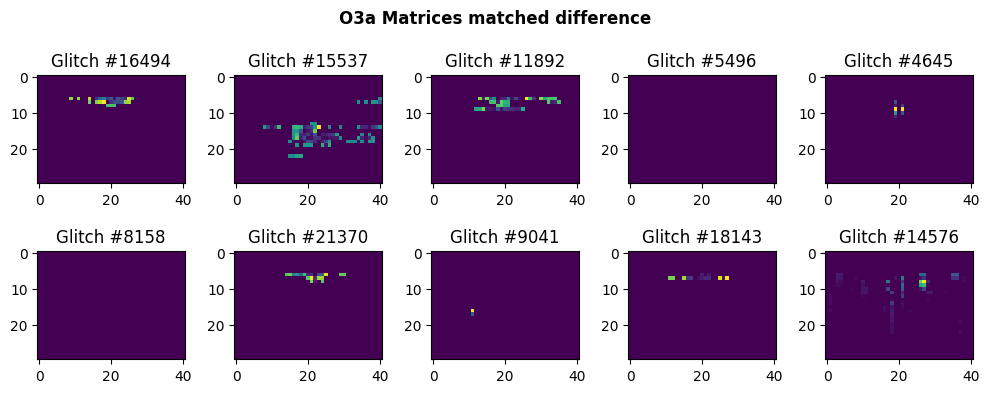

In [285]:
plot_comparison(indices_sorteados, matrice_diff, 'matched difference', run)

By examining the glitchgrams from our clustering process and Gravity Spy, we concluded that our match is correct. 

The difference glitchgrams confirm that the data are not identical but merely exhibit a slight temporal offset relative to each other.

### Generate NON_MATCHED glitchgrams

In [289]:
cluster1 = non_matched_gdchar.copy()
cluster2 = non_matched_gspy.copy()

clustered_gdchar = cluster1[['time', 'frequency', 'snr']]
clustered_gspy = cluster2[['GPStime', 'peakFreq', 'snr']].rename(columns={'GPStime': 'time'})

In [290]:
len(clustered_gdchar)

58252

In [291]:
len(clustered_gspy)

23144

In [292]:
matrices_nomatch_gdchar = glitch_to_glitchgram(unclustered, clustered_gdchar, deltat)
matrices_nomatch_gspy = glitch_to_glitchgram(unclustered, clustered_gspy, deltat)

In [293]:
arr_gdchar1 = np.array(matrices_nomatch_gdchar)
arr_gspy2 = np.array(matrices_nomatch_gspy)

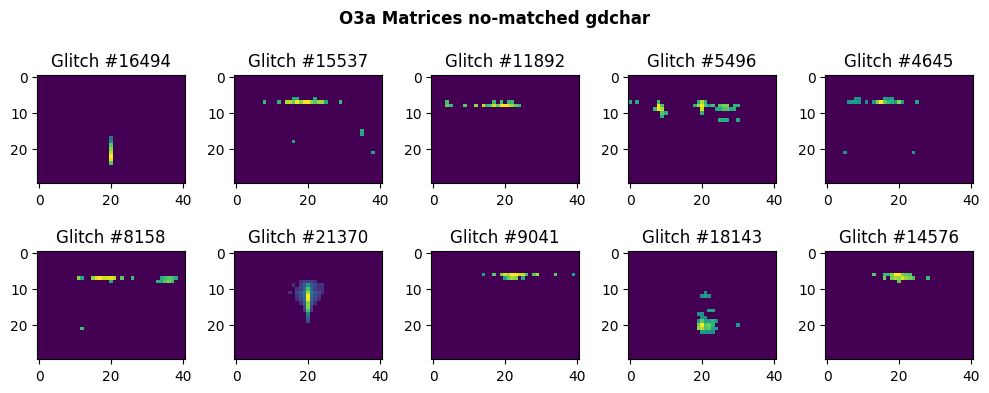

In [301]:
plot_comparison(indices_sorteados, arr_gdchar1, 'no-matched gdchar', run)

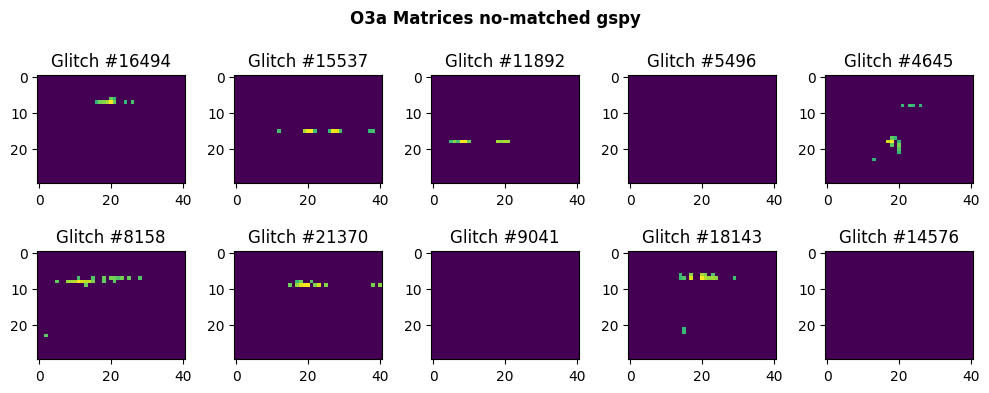

In [302]:
plot_comparison(indices_sorteados, arr_gspy2, 'no-matched gspy', run)

In [257]:
matrizes_matched_gdchar = glitch_to_glitchgram(unclustered, clustered_gdchar, deltat)
matrizes_matched_gspy = glitch_to_glitchgram(unclustered, clustered_gspy, deltat)

arr_gdchar = np.array(matrizes_matched_gdchar)
arr_gspy = np.array(matrizes_matched_gspy)

### Glitchgrams comparison

In [258]:
seed = 17
np.random.seed(seed)

num_total = len(matrizes_matched_gdchar)
indices_sorteados = np.random.choice(num_total, size=10, replace=False)

indices_sorteados

array([18988,   896, 17788, 12010,   991,   674, 19047,  7223,  6362,
       11055])

In [259]:
def plot_comparison(indices_sorteados, array, name, run):
    fig, axes = plt.subplots(2, 5, figsize=(10,4))
    axes = axes.flatten()
    
    fig.suptitle(f"{run} Matrices {name}", fontsize=12, fontweight='bold')
    
    for i, idx in enumerate(indices_sorteados):
        
        matriz = array[idx]
        ax = axes[i]
        
        im = ax.imshow(matriz)
        ax.set_title(f"Glitch #{idx}")
    
    plt.tight_layout()
    plt.show()

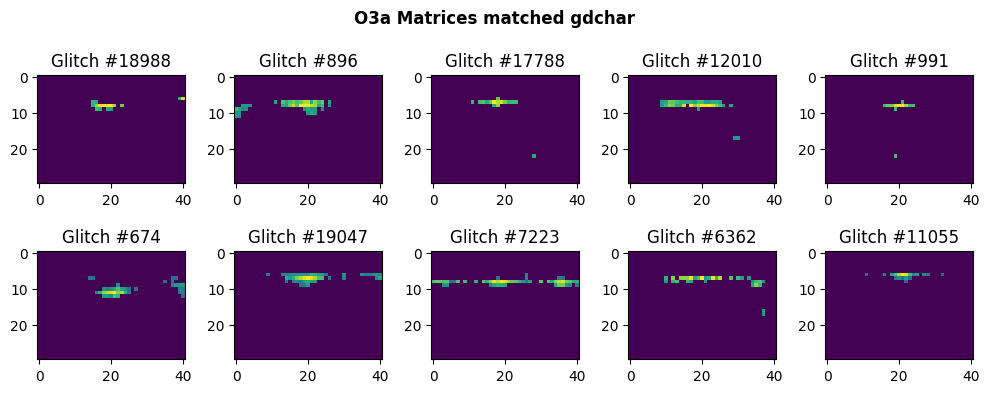

In [260]:
plot_comparison(indices_sorteados, arr_gdchar, 'matched gdchar', run)

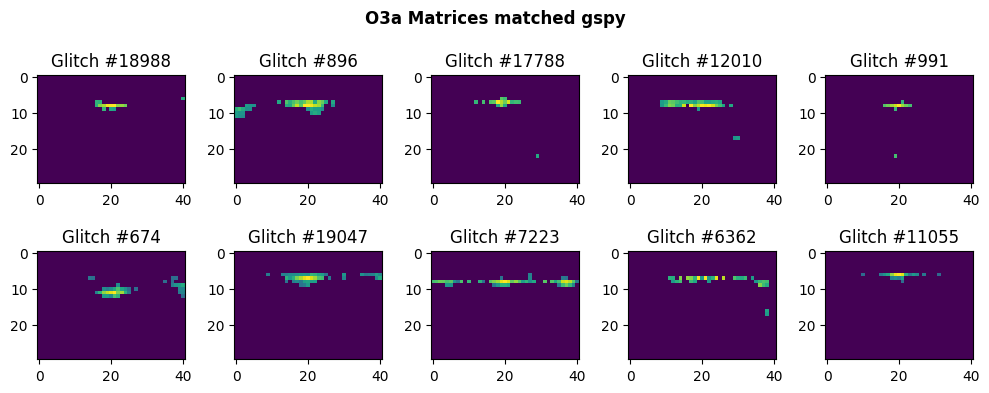

In [261]:
plot_comparison(indices_sorteados, arr_gspy, 'matched gspy', run)

In [262]:
matrix_diff = abs(arr_gdchar - arr_gspy)

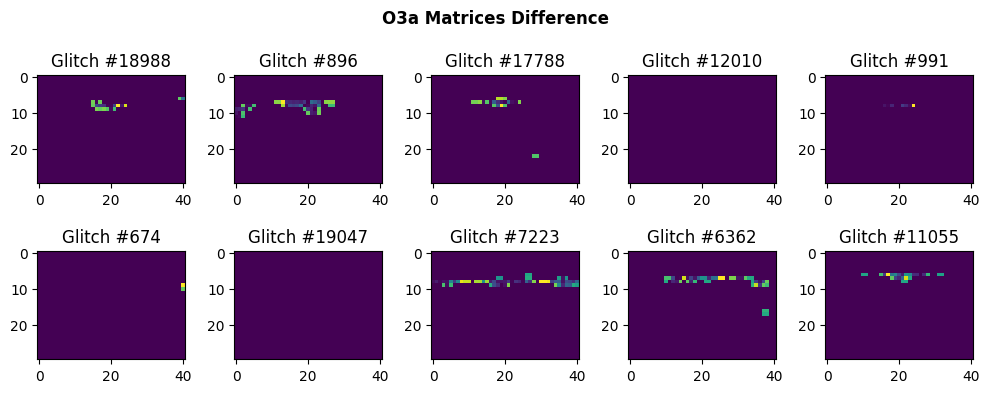

In [263]:
plot_comparison(indices_sorteados, matrix_diff, 'Difference', run)

By examining the glitchgrams from our clustering process and Gravity Spy, we concluded that our match is correct. 

The difference glitchgrams confirm that the data are not identical but merely exhibit a slight temporal offset relative to each other.

### Generate NON_MATCHED glitchgrams

In [264]:
non_matched_gdchar.tail()

,time,frequency,snr
58247,1.253974e+09,27.906247,7.632426
58248,1.253975e+09,32.842241,12.071470
58249,1.253977e+09,1079.892919,89.686901
58250,1.253977e+09,20.317121,8.158477
58251,1.253977e+09,22.811897,7.658416


In [265]:
non_matched_gspy.tail()

,GPStime,peakFreq,snr,amplitude,centralFreq,duration,bandwidth,chisq,chisqDof,confidence,id,ifo,label,imgUrl,Q-value
23139,1.253972e+09,31.018,7.961,3.720000e-22,30.500,1.156,12.218920,0.0,0.0,0.959,56KvhkOCa5,V1,None_of_the_Above,https://ldas-jobs.ligo.caltech.edu/~gravityspy...,11.314
23140,1.253972e+09,26.904,8.155,4.320000e-22,2169.502,1.500,4307.003418,0.0,0.0,0.998,L4j9cv8xTN,V1,Scattered_Light,https://ldas-jobs.ligo.caltech.edu/~gravityspy...,45.255
23141,1.253974e+09,28.770,10.982,4.620000e-22,36.338,2.250,40.676109,0.0,0.0,1.000,bZxeYIHNwV,V1,Scattered_Light,https://ldas-jobs.ligo.caltech.edu/~gravityspy...,45.255
23142,1.253974e+09,30.278,12.798,4.350000e-22,592.631,1.750,1153.261353,0.0,0.0,1.000,khoKF0Cjhf,V1,Scattered_Light,https://ldas-jobs.ligo.caltech.edu/~gravityspy...,45.255
23143,1.253975e+09,19.896,7.619,1.410000e-21,3909.822,1.500,7783.627441,0.0,0.0,0.991,8WQeFNzWf4,V1,Low_Frequency_Lines,https://ldas-jobs.ligo.caltech.edu/~gravityspy...,45.255


In [266]:
gdchar = non_matched_gdchar.copy()
gspy = non_matched_gspy.copy()

gdchar_nomatched = gdchar[['time', 'frequency', 'snr']]
gspy_nomatched = gspy[['GPStime', 'peakFreq', 'snr']].rename(columns={'GPStime': 'time'})

In [267]:
matrizes_non_matched_gdchar = glitch_to_glitchgram(unclustered, gdchar_nomatched, deltat)
matrizes_non_matched_gspy = glitch_to_glitchgram(unclustered, gspy_nomatched, deltat)

arr_gdchar = np.array(matrizes_matched_gdchar)
arr_gspy = np.array(matrizes_matched_gspy)

### Glitchgrams comparison

In [248]:
'''seed = 17
np.random.seed(seed)

num_total = len(arr_gdchar)
indices_gdchar = np.random.choice(num_total, size=10, replace=False)

indices_gdchar'''

array([18988,   896, 17788, 12010,   991,   674, 19047,  7223,  6362,
       11055])

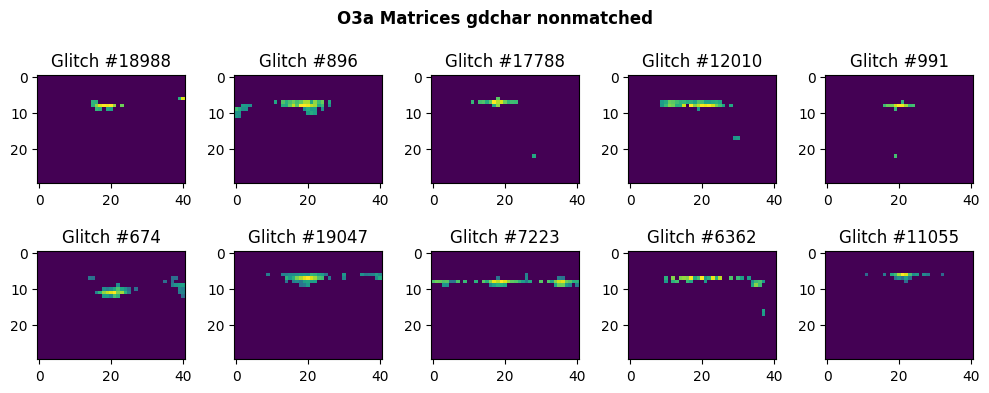

In [268]:
plot_comparison(indices_sorteados, arr_gdchar, 'gdchar nonmatched', run)

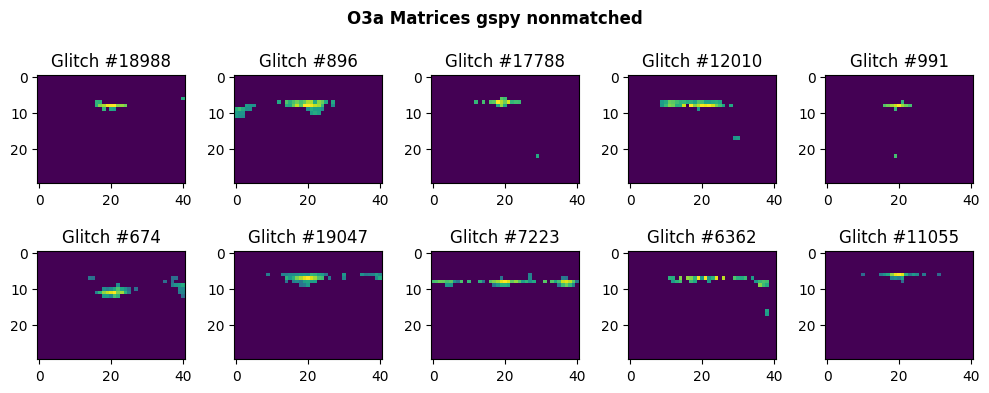

In [269]:
plot_comparison(indices_sorteados, arr_gspy, 'gspy nonmatched', run)

In [270]:
matrix_diff2 = abs(arr_gdchar - arr_gspy)

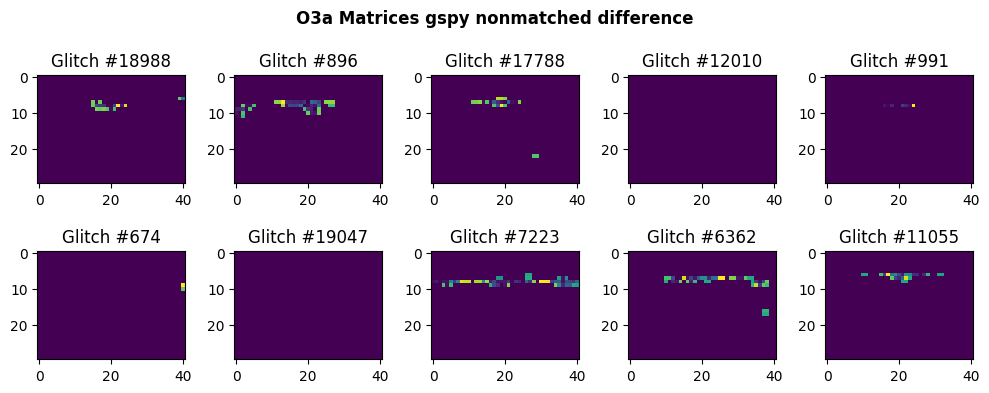

In [271]:
plot_comparison(indices_sorteados, matrix_diff2, 'gspy nonmatched difference', run)

## Observe the gitchgrams from O3b

### Read the triggers

In [ ]:
tperc, trigg_size = 0.7, 359385802
trigcols = ['time', 'frequency', 'snr']
ntrig = int(trigg_size*tperc)

In [176]:
base

'/home/esanches/Projetos/tSNE/Virgo'

In [ ]:
""" Performs a random and filtered read of a large CSV file to save memory """

np.random.seed(42)
skip_logic = lambda i: i > 0 and np.random.random() > tperc
trigg = pd.read_csv(base + '/' + 'triggers_total.csv', skiprows=skip_logic, usecols=trigcols)
trigg = trigg.sort_values('time').reset_index(drop=True)
unclustered = trigg.copy()

In [ ]:
unclustered.tail()

### Generate the glitchgrams

In [177]:
non_matched

,GPStime,peakFreq,snr_x,amplitude,centralFreq,duration,bandwidth,chisq,chisqDof,confidence,id,ifo,label,imgUrl,Q-value,time,frequency,snr_y
0,1.238167e+09,41.312,8.180,2.460000e-22,65.530,0.078,82.279373,0.0,0.0,1.000,7Rmzlmneu5,V1,Blip,https://ldas-jobs.ligo.caltech.edu/~gravityspy...,5.657,NaN,NaN,NaN
1,1.238167e+09,19.056,8.306,3.290000e-21,19.370,1.750,2.439150,0.0,0.0,0.965,pwXEfq8DlK,V1,Low_Frequency_Lines,https://ldas-jobs.ligo.caltech.edu/~gravityspy...,45.255,NaN,NaN,NaN
2,1.238169e+09,337.003,8.768,1.280000e-22,386.276,0.109,160.479645,0.0,0.0,0.993,kSRAAs7wyx,V1,Whistle,https://ldas-jobs.ligo.caltech.edu/~gravityspy...,45.255,NaN,NaN,NaN
3,1.238169e+09,340.202,8.732,1.360000e-22,3176.268,0.154,5737.409180,0.0,0.0,0.995,hfAIRa8dhr,V1,Whistle,https://ldas-jobs.ligo.caltech.edu/~gravityspy...,45.255,NaN,NaN,NaN
4,1.238169e+09,337.003,16.599,2.600000e-22,357.194,0.453,218.644699,0.0,0.0,0.999,r1DKM8xvDP,V1,Whistle,https://ldas-jobs.ligo.caltech.edu/~gravityspy...,45.255,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23106,1.253972e+09,31.018,7.961,3.720000e-22,30.500,1.156,12.218920,0.0,0.0,0.959,56KvhkOCa5,V1,None_of_the_Above,https://ldas-jobs.ligo.caltech.edu/~gravityspy...,11.314,NaN,NaN,NaN
23107,1.253972e+09,26.904,8.155,4.320000e-22,2169.502,1.500,4307.003418,0.0,0.0,0.998,L4j9cv8xTN,V1,Scattered_Light,https://ldas-jobs.ligo.caltech.edu/~gravityspy...,45.255,NaN,NaN,NaN
23108,1.253974e+09,28.770,10.982,4.620000e-22,36.338,2.250,40.676109,0.0,0.0,1.000,bZxeYIHNwV,V1,Scattered_Light,https://ldas-jobs.ligo.caltech.edu/~gravityspy...,45.255,NaN,NaN,NaN
23109,1.253974e+09,30.278,12.798,4.350000e-22,592.631,1.750,1153.261353,0.0,0.0,1.000,khoKF0Cjhf,V1,Scattered_Light,https://ldas-jobs.ligo.caltech.edu/~gravityspy...,45.255,NaN,NaN,NaN


In [ ]:
cluster = non_matched.copy()

clustered_gdchar = cluster[['time', 'frequency', 'snr_x']]
clustered_gspy = cluster[['GPStime', 'peakFreq', 'snr_y']].rename(columns={'GPStime': 'time'})

In [99]:
matrizes_matched_gdchar = glitch_to_glitchgram(unclustered, clustered_gdchar, deltat)
matrizes_matched_gspy = glitch_to_glitchgram(unclustered, clustered_gspy, deltat)

arr_gdchar = np.array(matrizes_matched_gdchar)
arr_gspy = np.array(matrizes_matched_gspy)